In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
data = pd.read_csv(r'X:\PROJETS\PYTHON\systeme_prediction_panne_electricite\backend\data\snel_equipment_data.csv')

In [106]:
data

,type_materiel,capacite_max_kw,consommation_kw,tension_v,panne
0,Armoire de Distribution Publique,150,141.12,212.2,0
1,Transformateur 100 kVA,80,101.36,174.2,1
2,Disjoncteur Depart HTA,1200,1021.55,176.2,1
3,Armoire de Distribution Publique,150,148.64,225.7,0
4,Transformateur 250 kVA,200,176.29,211.2,0
...,...,...,...,...,...
9995,Transformateur 250 kVA,200,167.17,212.4,0
9996,Disjoncteur Depart HTA,1200,1304.85,209.6,1
9997,Transformateur 400 kVA,320,344.00,215.8,0
9998,Transformateur 250 kVA,200,125.74,172.2,0


# ANALYSE EXPLORATOIRE DE DONNEES

In [107]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type_materiel    10000 non-null  object 
 1   capacite_max_kw  10000 non-null  int64  
 2   consommation_kw  10000 non-null  float64
 3   tension_v        10000 non-null  float64
 4   panne            10000 non-null  int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 390.8+ KB


In [108]:
data.describe()

,capacite_max_kw,consommation_kw,tension_v,panne
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,567.193000,531.635549,198.499990,0.543300
std,519.502665,507.447231,16.455392,0.498146
min,80.000000,36.750000,170.000000,0.000000
25%,150.000000,147.320000,184.275000,0.000000
50%,320.000000,295.885000,198.500000,1.000000
75%,1200.000000,940.885000,212.725000,1.000000
max,1500.000000,2134.750000,227.000000,1.000000


In [109]:
data.dtypes

type_materiel       object
capacite_max_kw      int64
consommation_kw    float64
tension_v          float64
panne                int64
dtype: object

In [110]:
pd.crosstab(data["type_materiel"],data["panne"],normalize="index") * 100

panne,0,1
type_materiel,,
Armoire de Distribution Publique,47.375787,52.624213
Cellule d Arrivee MT,46.072931,53.927069
Disjoncteur Depart HTA,45.423497,54.576503
Transformateur 100 kVA,44.683808,55.316192
Transformateur 250 kVA,46.369518,53.630482
Transformateur 400 kVA,43.487395,56.512605
Transformateur 630 kVA,46.310611,53.689389


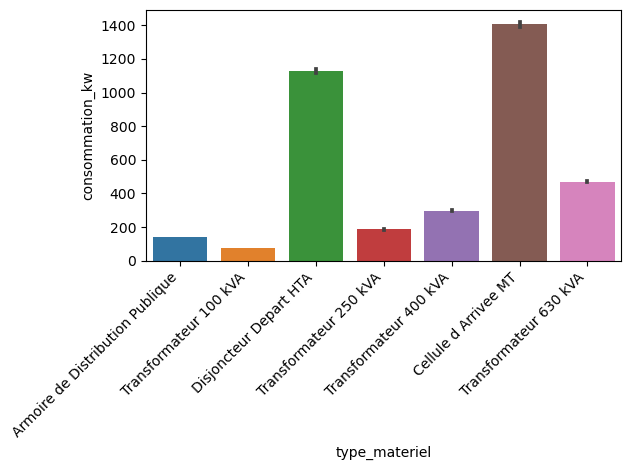

In [111]:
sns.barplot(data=data,y="consommation_kw",x="type_materiel")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()

In [112]:
data.isna().sum()

type_materiel      0
capacite_max_kw    0
consommation_kw    0
tension_v          0
panne              0
dtype: int64

<Axes: xlabel='panne', ylabel='count'>

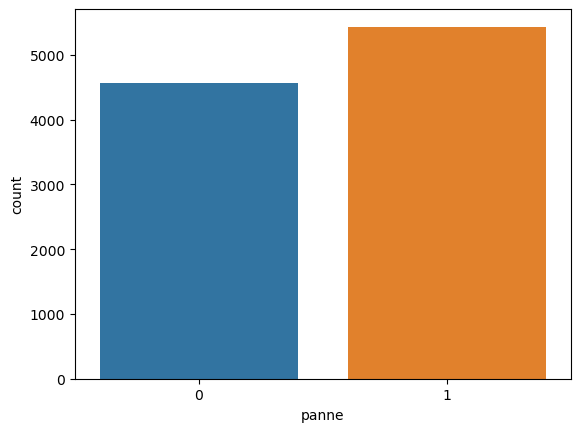

In [113]:
sns.countplot(data=data,x="panne")

In [114]:
data["panne"].value_counts(normalize=True) * 100

panne
1    54.33
0    45.67
Name: proportion, dtype: float64

# MATRICE DE CORRELATION

In [116]:
print(data.corr(numeric_only=True))

                 capacite_max_kw  consommation_kw  tension_v     panne
capacite_max_kw         1.000000         0.959766  -0.000477 -0.001291
consommation_kw         0.959766         1.000000  -0.007307  0.090422
tension_v              -0.000477        -0.007307   1.000000 -0.585042
panne                  -0.001291         0.090422  -0.585042  1.000000


# SEPARATION DE JEU DE DONNEES EN ENSEMBLE D'ENTRAINEMENT ET TEST

In [117]:
X = data.drop("panne",axis=1)
y = data["panne"]

In [118]:
from sklearn.model_selection import train_test_split

In [119]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# ENTRAINEMENT DU MODELE

In [120]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.compose import ColumnTransformer

In [125]:
preprocessor = ColumnTransformer([
    ("OneHotEncoder",OneHotEncoder(handle_unknown='ignore'),["type_materiel"])
                                ],remainder="passthrough")

In [126]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier())])

In [127]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OneHotEncoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type_materiel'])])),
                ('classifier', RandomForestClassifier())])

In [128]:
pipeline.score(X_test,y_test)

0.8325

# OPTIMISATION DES HYPERPARAMETRE DU MODELE

In [129]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [8, 10, 12, None],
    'classifier__min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
print('Meilleur score CV :', grid_search.best_score_)
print('Score Test :', best_pipeline.score(X_test, y_test))

Meilleur score CV : 0.845875
Score Test : 0.8445


# MATRICE DE CONFUSION

In [134]:
from sklearn.metrics import classification_report

y_pred = best_pipeline.predict(X_test)

report = classification_report(
    y_test,
    y_pred,
    target_names=['Normal (0)', 'Panne (1)'],
    digits=4, 
)

print('=' * 60)
print('          RAPPORT DE CLASSIFICATION DU MODÈLE SNEL')
print('=' * 60)
print(report)
print('=' * 60)

          RAPPORT DE CLASSIFICATION DU MODÈLE SNEL
              precision    recall  f1-score   support

  Normal (0)     0.8244    0.8379    0.8311       913
   Panne (1)     0.8619    0.8500    0.8560      1087

    accuracy                         0.8445      2000
   macro avg     0.8431    0.8440    0.8435      2000
weighted avg     0.8448    0.8445    0.8446      2000



# COURBE ROC

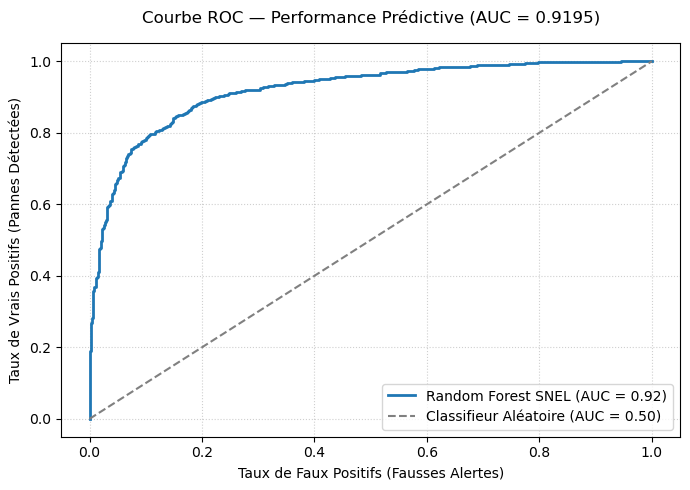

Score ROC-AUC : 0.9195


In [136]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

y_probs = best_pipeline.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_probs)

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    y_probs,
    name='Random Forest SNEL',
    ax=ax,
    color='#1f77b4',
    linewidth=2,
)

plt.plot(
    [0, 1],
    [0, 1],
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='Classifieur Aléatoire (AUC = 0.50)',
)

plt.title(
    f'Courbe ROC — Performance Prédictive (AUC = {auc_score:.4f})',
    fontsize=12,
    pad=15,
)
plt.xlabel('Taux de Faux Positifs (Fausses Alertes)', fontsize=10)
plt.ylabel('Taux de Vrais Positifs (Pannes Détectées)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

print(f'Score ROC-AUC : {auc_score:.4f}')

# SAUVEGARDE DU MODELE  

In [138]:
import os
import joblib

dossier_models = r'X:\PROJETS\PYTHON\systeme_prediction_panne_electricite\backend\models'
chemin_fichier = os.path.join(dossier_models, 'model.pkl')

os.makedirs(dossier_models, exist_ok=True)

joblib.dump(best_pipeline, chemin_fichier)

print('=' * 60)
print(f"[OK] Le modèle a été sauvegardé avec succès dans :\n{chemin_fichier}")
print('=' * 60)

[OK] Le modèle a été sauvegardé avec succès dans :
X:\PROJETS\PYTHON\systeme_prediction_panne_electricite\backend\models\model.pkl


In [139]:
pip freeze >> requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [143]:
data["panne"].value_counts()

panne
1    5433
0    4567
Name: count, dtype: int64

In [144]:
pip list

Package                           Version
--------------------------------- ------------
absl-py                           2.4.0
aiobotocore                       2.7.0
aiohttp                           3.9.3
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.12
altair                            5.0.1
anaconda-anon-usage               0.4.3
anaconda-catalogs                 0.2.0
anaconda-client                   1.12.3
anaconda-cloud-auth               0.1.4
anaconda-navigator                2.5.2
anaconda-project                  0.11.1
annotated-doc                     0.0.4
annotated-types                   0.7.0
anyio                             4.2.0
appdirs                           1.4.4
archspec                          0.2.1
argon2-cffi                       21.3.0
argon2-cffi-bindings              21.2.0
arrow                             1.2.3
astroid                           2.14.2
astropy                  